*Use this notebook to complete the sentence similarity and embedding visualization tasks.*


## Part 6 Inspecting and comparing embeddings

In [1]:
import torch
import numpy as np
import pickle
import nltk
nltk.download('punkt')
# A bug in my environment
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

# Tokenization function
def tokenize_text(text):
    return word_tokenize(text.lower())

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Morry\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


### Sentence Similarity

In [2]:
# List of sentences for comparison
sentences = [
    "The cat sat on the mat.",
    "A dog is playing in the yard.",
    "I need to buy groceries today.",
    "The feline was resting on the rug.",
    "Canines enjoy outdoor activities.",
    "My shopping list includes milk and bread.",
    "The weather is beautiful today.",
    "Programming requires logical thinking."
]

# Query sentence
query = "My pet cat is sleeping on the carpet."

In [3]:
# Function to compute cosine similarity
def cosine_similarity(vec1, vec2):
    return torch.dot(vec1, vec2) / (torch.norm(vec1) * torch.norm(vec2))

# Function to get sentence embedding
def get_sentence_embedding(sentence, embeddings, word2idx=None):
    tokens = tokenize_text(sentence)

    if word2idx is not None:
        vectors = [embeddings[word2idx[token]] for token in tokens if token in word2idx]
    else:
        vectors = [torch.from_numpy(embeddings[token]) for token in tokens if token in embeddings]

    if vectors:
        return torch.mean(torch.stack(vectors), dim=0)
    else:
        return torch.zeros(embeddings.size(1))

# Function to compute similarity between query and sentences
def compute_similarities(query, sentences, source, embeddings, word2idx=None):
    query_vector = get_sentence_embedding(query, embeddings, word2idx)

    similarities = {}
    for sent in sentences:
        sent_vector = get_sentence_embedding(sent, embeddings, word2idx)
        sim = cosine_similarity(query_vector, sent_vector)
        similarities[sent] = sim.item()
        print(f"Similarity between '{query}' and '{sent}': {sim.item():.4f}")
    
    return similarities

In [4]:
# Load pytorch word2vec embeddings
with open('word2vec_embeddings.pkl', 'rb') as f:
    data = pickle.load(f)

pt_embeddings = data['embeddings']
pt_word2idx = data['word2idx']
pt_idx2word = data['idx2word']

# Load other embeddings
from gensim.models import KeyedVectors
# Gensim Word2Vec
with open('word2vec_gensim_embeddings.pkl', 'rb') as f:
    gsm_data = pickle.load(f)
gsm_embeddings = torch.as_tensor(gsm_data['embeddings'])
gsm_word2idx = gsm_data['word2idx']

# Google News and FastText
google_model = KeyedVectors.load('word2vec-google-news-300.model')
fasttext_model = KeyedVectors.load('fasttext-wiki-news-subwords-300.model')

In [5]:
pt_similarities = compute_similarities(query, sentences, 'pytorch', pt_embeddings, pt_word2idx)

Similarity between 'My pet cat is sleeping on the carpet.' and 'The cat sat on the mat.': 0.7433
Similarity between 'My pet cat is sleeping on the carpet.' and 'A dog is playing in the yard.': 0.3863
Similarity between 'My pet cat is sleeping on the carpet.' and 'I need to buy groceries today.': 0.4772
Similarity between 'My pet cat is sleeping on the carpet.' and 'The feline was resting on the rug.': 0.2936
Similarity between 'My pet cat is sleeping on the carpet.' and 'Canines enjoy outdoor activities.': 0.3627
Similarity between 'My pet cat is sleeping on the carpet.' and 'My shopping list includes milk and bread.': 0.4622
Similarity between 'My pet cat is sleeping on the carpet.' and 'The weather is beautiful today.': 0.5202
Similarity between 'My pet cat is sleeping on the carpet.' and 'Programming requires logical thinking.': 0.5568


In [6]:
gsm_similarities = compute_similarities(query, sentences, 'gensim', gsm_embeddings, gsm_word2idx)

Similarity between 'My pet cat is sleeping on the carpet.' and 'The cat sat on the mat.': 0.7286
Similarity between 'My pet cat is sleeping on the carpet.' and 'A dog is playing in the yard.': 0.5951
Similarity between 'My pet cat is sleeping on the carpet.' and 'I need to buy groceries today.': 0.1789
Similarity between 'My pet cat is sleeping on the carpet.' and 'The feline was resting on the rug.': 0.5102
Similarity between 'My pet cat is sleeping on the carpet.' and 'Canines enjoy outdoor activities.': 0.0863
Similarity between 'My pet cat is sleeping on the carpet.' and 'My shopping list includes milk and bread.': 0.4660
Similarity between 'My pet cat is sleeping on the carpet.' and 'The weather is beautiful today.': 0.4918
Similarity between 'My pet cat is sleeping on the carpet.' and 'Programming requires logical thinking.': 0.0676


In [7]:
google_similarities = compute_similarities(query, sentences, 'google', google_model)

Similarity between 'My pet cat is sleeping on the carpet.' and 'The cat sat on the mat.': 0.7369
Similarity between 'My pet cat is sleeping on the carpet.' and 'A dog is playing in the yard.': 0.6483
Similarity between 'My pet cat is sleeping on the carpet.' and 'I need to buy groceries today.': 0.3718
Similarity between 'My pet cat is sleeping on the carpet.' and 'The feline was resting on the rug.': 0.7794
Similarity between 'My pet cat is sleeping on the carpet.' and 'Canines enjoy outdoor activities.': 0.4281
Similarity between 'My pet cat is sleeping on the carpet.' and 'My shopping list includes milk and bread.': 0.4970
Similarity between 'My pet cat is sleeping on the carpet.' and 'The weather is beautiful today.': 0.4310
Similarity between 'My pet cat is sleeping on the carpet.' and 'Programming requires logical thinking.': 0.2979


C:\Users\Morry\AppData\Local\Temp\ipykernel_48760\2822167933.py:12: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  vectors = [torch.from_numpy(embeddings[token]) for token in tokens if token in embeddings]


In [8]:
fasttext_similarities = compute_similarities(query, sentences, 'fasttext', fasttext_model)

Similarity between 'My pet cat is sleeping on the carpet.' and 'The cat sat on the mat.': 0.9114
Similarity between 'My pet cat is sleeping on the carpet.' and 'A dog is playing in the yard.': 0.8512
Similarity between 'My pet cat is sleeping on the carpet.' and 'I need to buy groceries today.': 0.5858
Similarity between 'My pet cat is sleeping on the carpet.' and 'The feline was resting on the rug.': 0.9247
Similarity between 'My pet cat is sleeping on the carpet.' and 'Canines enjoy outdoor activities.': 0.6504
Similarity between 'My pet cat is sleeping on the carpet.' and 'My shopping list includes milk and bread.': 0.8350
Similarity between 'My pet cat is sleeping on the carpet.' and 'The weather is beautiful today.': 0.8090
Similarity between 'My pet cat is sleeping on the carpet.' and 'Programming requires logical thinking.': 0.6135


### Embedding Visualization

In [9]:
# Load packages
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import umap
import numpy as np

d:\miniconda3\envs\stat359\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:

categories = {
    'animals': ['dog', 'cat', 'horse', 'cow', 'lion', 'tiger', 'elephant', 'giraffe', 
                'eagle', 'hawk', 'sparrow', 'penguin', 'shark', 'whale', 'dolphin', 'tuna'],
    'foods': ['apple', 'orange', 'banana', 'grape', 'bread', 'pasta', 'rice', 'potato', 
              'chicken', 'beef', 'pork', 'fish', 'coffee', 'tea', 'juice', 'water'],
    'professions': ['doctor', 'nurse', 'engineer', 'teacher', 'lawyer', 'artist', 'scientist', 
                    'farmer', 'writer', 'artist', 'musician', 'dancer', 'actor']
}

In [11]:
def get_vectors(model_obj, word2idx=None):
    all_vecs = []
    all_labels = []
    all_colors = []
    
    color_map = {'animals': 'blue', 'foods': 'orange', 'professions': 'green'}
    
    for category, words in categories.items():
        for word in words:
            # get word vectors
            vec = None
            if word2idx is not None:
                vec = model_obj[word2idx[word]]
            else:
                vec = model_obj[word]
            
            if vec is not None:
                # transform to numpy for plotting
                if isinstance(vec, torch.Tensor):
                    vec = vec.detach().cpu().numpy()
                all_vecs.append(vec)
                all_labels.append(word)
                all_colors.append(color_map[category])
                
    return np.array(all_vecs), all_labels, all_colors

In [12]:
def plot_embeddings(data_sources):
    # each row is a model, two columns: t-SNE and UMAP
    n_models = len(data_sources)
    fig, axes = plt.subplots(n_models, 2, figsize=(18, 6 * n_models))
    
    for idx, (name, model, w2idx) in enumerate(data_sources):
        # get word vectors
        vecs, labels, colors = get_vectors(model, w2idx)
        
        # t-SNE data
        tsne = TSNE(n_components=2, perplexity=10, random_state=42, init='pca', learning_rate='auto')
        reduced_tsne = tsne.fit_transform(vecs)
        
        # UMAP data
        reducer = umap.UMAP(n_neighbors=5, min_dist=0.3, metric='cosine', random_state=42)
        reduced_umap = reducer.fit_transform(vecs)
        
        # t-SNE plotting
        ax_tsne = axes[idx, 0]
        for i, label in enumerate(labels):
            ax_tsne.scatter(reduced_tsne[i, 0], reduced_tsne[i, 1], c=colors[i], edgecolors='k', s=100)
            ax_tsne.annotate(label, (reduced_tsne[i, 0]+0.1, reduced_tsne[i, 1]+0.1), fontsize=9)
        ax_tsne.set_title(f"t-SNE: {name}", fontsize=14)
        ax_tsne.grid(True, linestyle='--', alpha=0.5)

        # UMAP plotting
        ax_umap = axes[idx, 1]
        for i, label in enumerate(labels):
            ax_umap.scatter(reduced_umap[i, 0], reduced_umap[i, 1], c=colors[i], edgecolors='k', s=100)
            ax_umap.annotate(label, (reduced_umap[i, 0]+0.1, reduced_umap[i, 1]+0.1), fontsize=9)
        ax_umap.set_title(f"UMAP: {name}", fontsize=14)
        ax_umap.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()


d:\miniconda3\envs\stat359\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
d:\miniconda3\envs\stat359\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
d:\miniconda3\envs\stat359\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
d:\miniconda3\envs\stat359\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


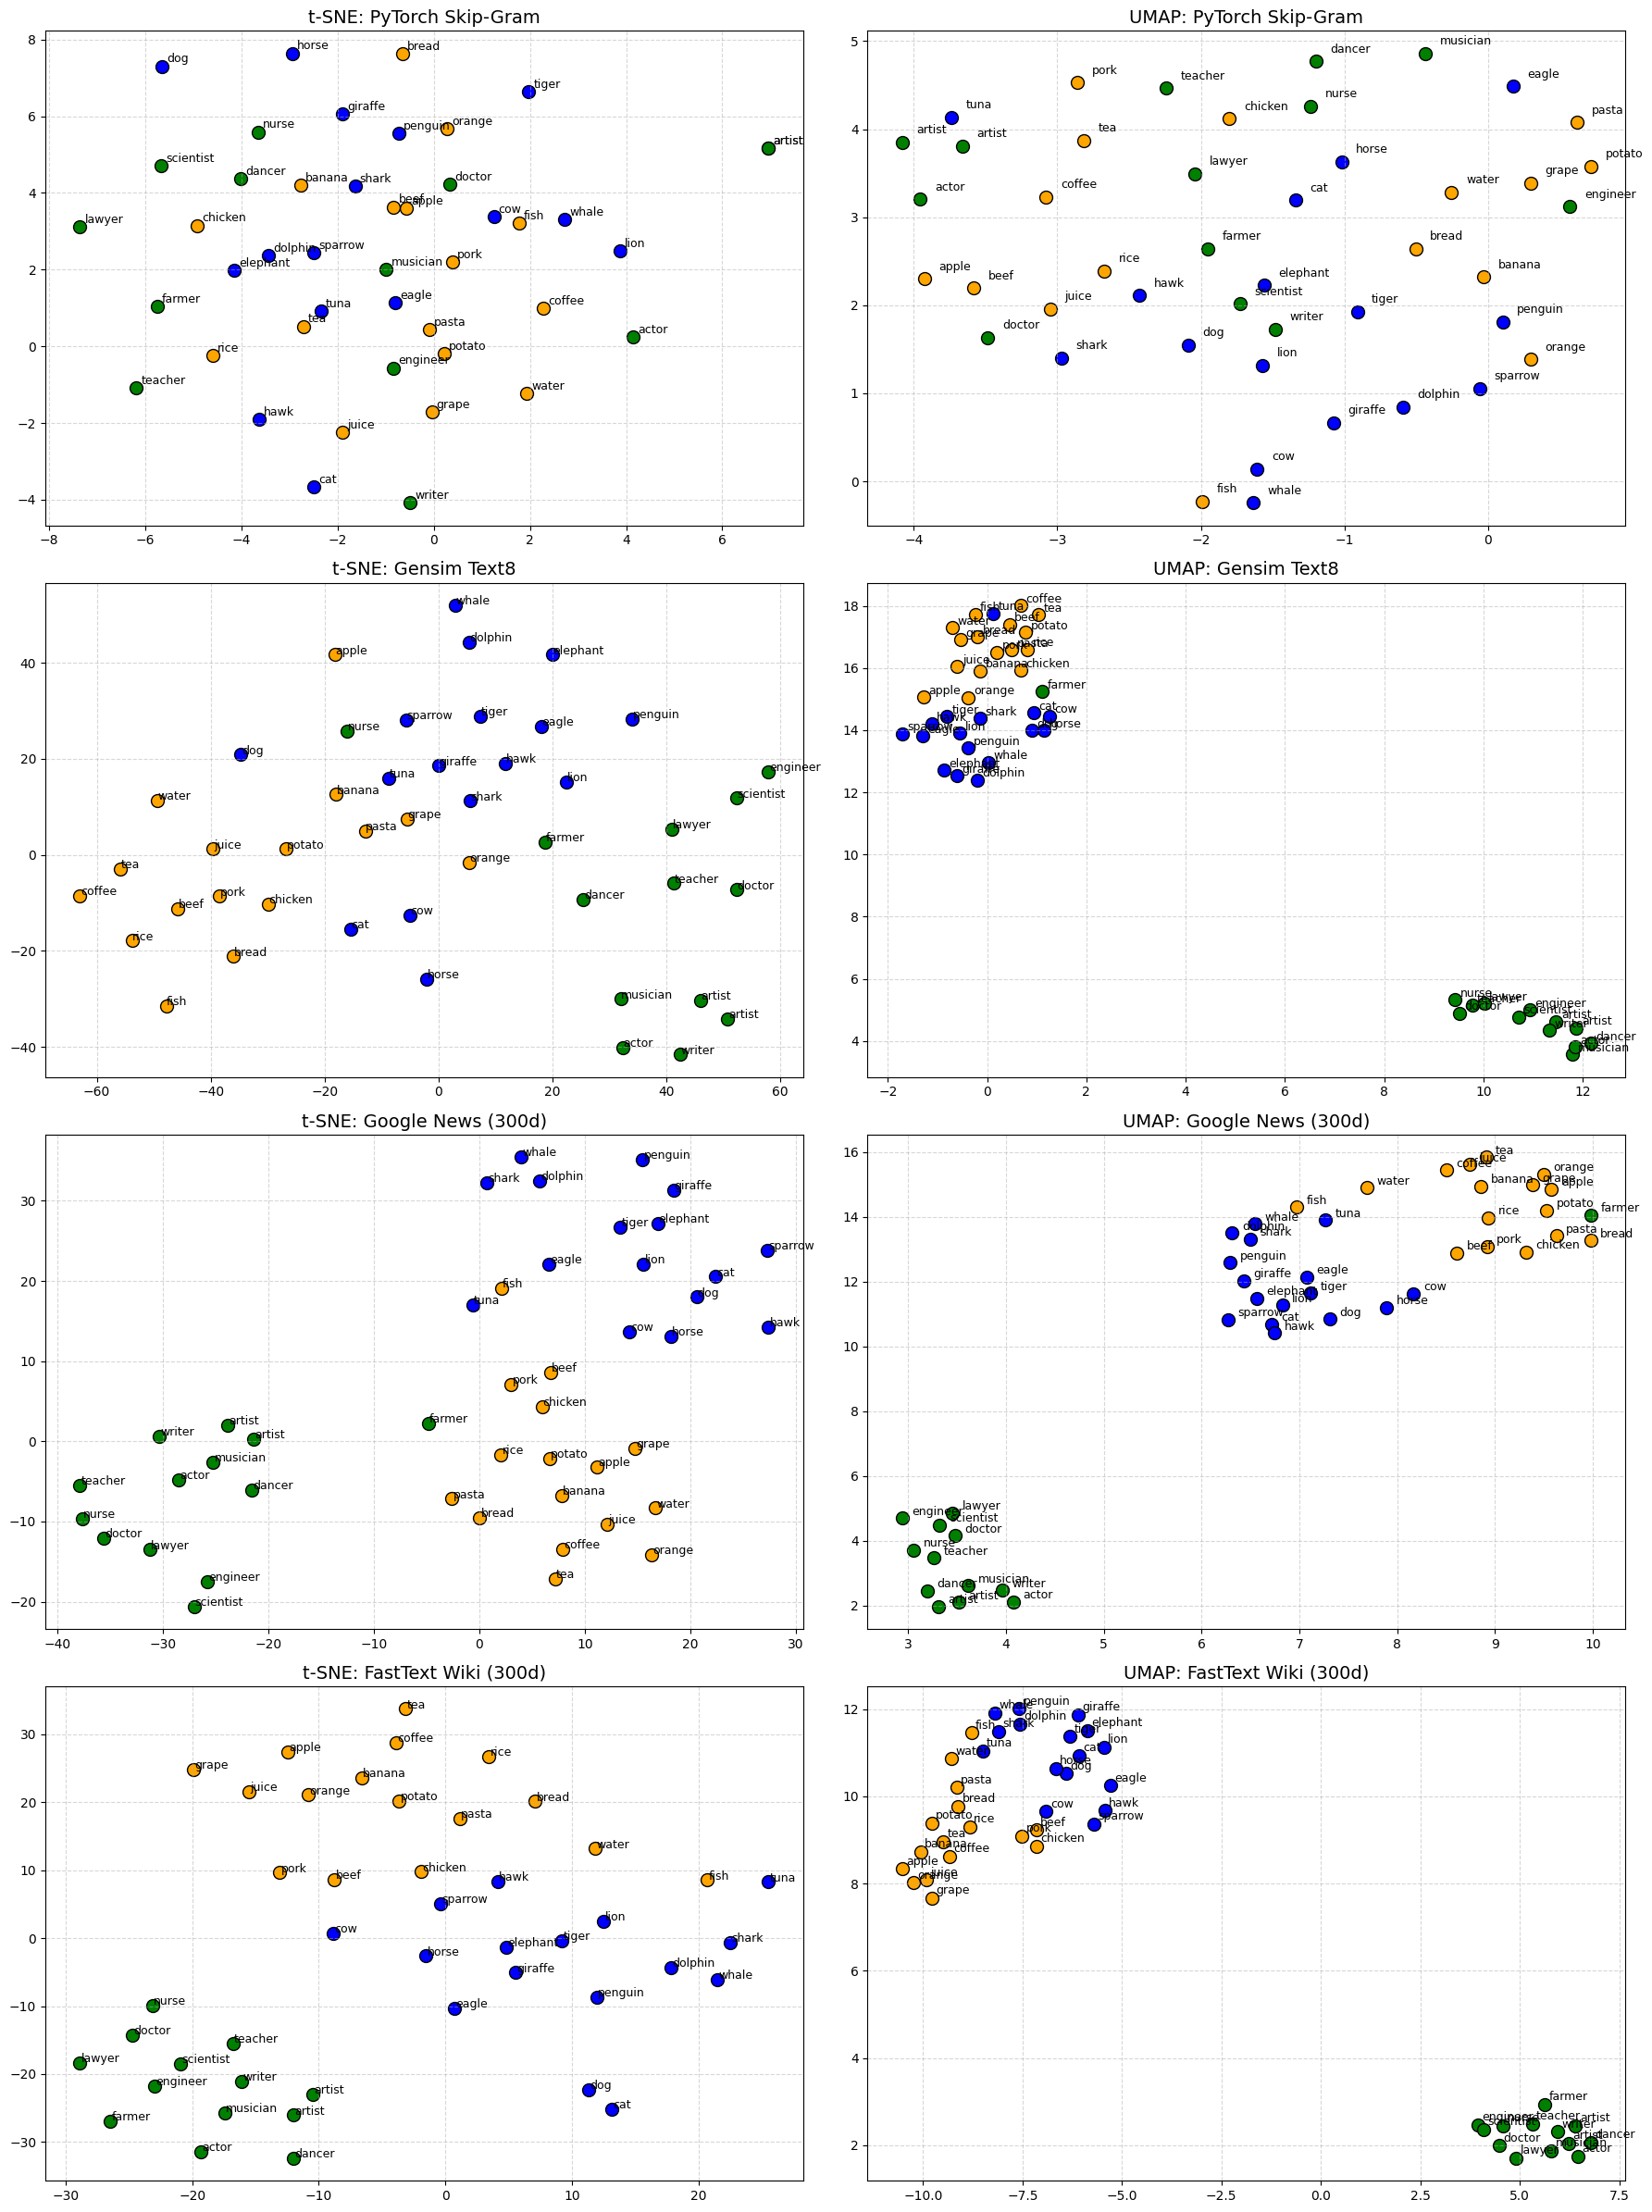

In [13]:
data_sources = [
    ("PyTorch Skip-Gram", pt_embeddings, pt_word2idx),
    ("Gensim Text8", gsm_embeddings, gsm_word2idx),
    ("Google News (300d)", google_model, None),
    ("FastText Wiki (300d)", fasttext_model, None)
]
plot_embeddings(data_sources)

## Part 7 Short Answer Questions

**Which embeddings performed best at capturing sentence meaning?**

Gensim Word2Vec (Google) and Gensim FastText performed best.

**Were the pretrained embeddings significantly better than your own? Why or why not?**

Yes, the pretrained embeddings are better. I think there are several reasons:

1. These pretrained models are trained on larger data set
2. Their hyperparameters are well tuned

**What factors might explain the differences in performance?**

The data on which model are trained made the differences. Text8 is the corpus from Wikipedia, which is definitely different from the corpus from Google News. For example, given a word as center, its frequency and context will be different in these two data, causing different word embedding.

## Part 8: AI Use Disclosure (Required)

If you used any AI-enabled tools (e.g., ChatGPT, GitHub Copilot, Claude, or other LLM assistants) while working on this assignment, you must disclose that use here. The goal is transparency-not punishment.

In your disclosure, briefly include:
- **Tool(s) used:** (name + version if known)
- **How you used them:** (e.g., concept explanation, debugging, drafting code, rewriting text)
- **What you verified yourself:** (e.g., reran the notebook, checked outputs/plots, checked shapes, read documentation)
- **What you did *not* use AI for (if applicable):** (optional)

You are responsible for the correctness of your submission, even if AI suggested code or explanations.

#### <font color="red">Write your disclosure here.</font>


- **Tool(s) used:** Gemeni 3
- **How you used them:** module explanation, debugging, plotting function framework
- **What you verified yourself:** checked outputs
- **What you did *not* use AI for (if applicable):** function code